# 02 - Regularization Shift in Double Descent (Attempt 8b Baseline)

This notebook explores how explicit regularization (weight decay) and other factors shift the double descent phenomenon in overparameterized MLPs. We use a teacher-student regression framework based on **Attempt 8b**, utilizing a Frozen-first-layer MLP trained to interpolation.

In [38]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import sys

# Setup repo access
REPO_ROOT = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src.teacher_student import FrozenTwoLayerReLU, make_linear_teacher_regression, count_params
from src.train import train_regression

def seed_all(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Global Parameters (Attempt 8b)
SEED = 14
N_TRAIN = 256
N_TEST = 4096
D_IN = 50
NOISE_STD = 0.5
TARGET_MSE = 1e-8


Using device: cpu


Interpolation starts at m = 260


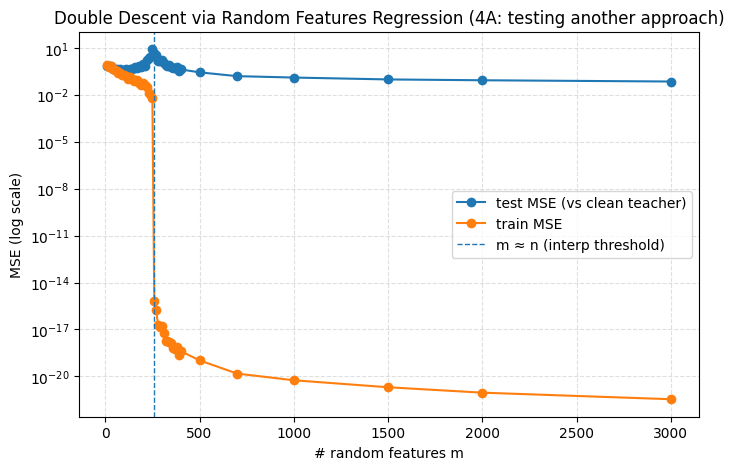

In [39]:
#replicate Jay's chart

# Attempt 4A: Random Features Regression (clean, paper-style double descent)
rng = np.random.default_rng(SEED)

# --- DGP ---
n_train = 256
n_test  = 4096
d_in    = 50
noise_std = 0.5

Xtr = rng.standard_normal((n_train, d_in))
Xte = rng.standard_normal((n_test,  d_in))

# teacher is linear in input space (clean + stable)
w_star = rng.standard_normal(d_in) / np.sqrt(d_in)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + noise_std * rng.standard_normal(n_train)
yte = yte_clean  # evaluate against clean teacher

# normalize targets (optional but makes scales nice)
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

# --- Random feature map: phi(x) = relu(Wx / sqrt(d)) ---
def relu(z): return np.maximum(z, 0.0)

# Sweep #features m (capacity)
ms = list(range(10, 401, 10)) + [500, 700, 1000, 1500, 2000, 3000]

train_mse = []
test_mse  = []

# small ridge for numerical stability; set to 0.0 if you want pure interpolation
ridge = 1e-8

for m in ms:
    W = rng.standard_normal((m, d_in)) / np.sqrt(d_in)  # fixed random first layer

    Phi_tr = relu(Xtr @ W.T)  # (n, m)
    Phi_te = relu(Xte @ W.T)

    # Solve ridge regression in feature space:
    # beta = argmin ||Phi beta - y||^2 + ridge ||beta||^2
    # Closed form: beta = (Phi^T Phi + ridge I)^(-1) Phi^T y
    A = Phi_tr.T @ Phi_tr + ridge * np.eye(m)
    b = Phi_tr.T @ ytr
    beta = np.linalg.solve(A, b)

    yhat_tr = Phi_tr @ beta
    yhat_te = Phi_te @ beta

    train_mse.append(np.mean((yhat_tr - ytr) ** 2))
    test_mse.append(np.mean((yhat_te - yte) ** 2))

# --- Plot double descent ---
plt.figure(figsize=(8,5))
plt.plot(ms, test_mse, marker="o", label="test MSE (vs clean teacher)")
plt.plot(ms, train_mse, marker="o", label="train MSE")
plt.axvline(n_train, linestyle="--", linewidth=1, label="m ≈ n (interp threshold)")
plt.yscale("log")
plt.xlabel("# random features m")
plt.ylabel("MSE (log scale)")
plt.title("Double Descent via Random Features Regression (4A: testing another approach)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()

interp_idx = np.where(np.array(train_mse) < 1e-8)[0][0]
print("Interpolation starts at m =", ms[interp_idx])
plt.show()

## Experiment 1: Weight Decay Sweep
Observe how increasing weight decay flattens the secondary peak around interpolation threshold $m = 256$.

"How does the shape of the double descent curve change when we use different amounts of regularization?"

Interpolation (for wd=1e-8) starts at m = 260


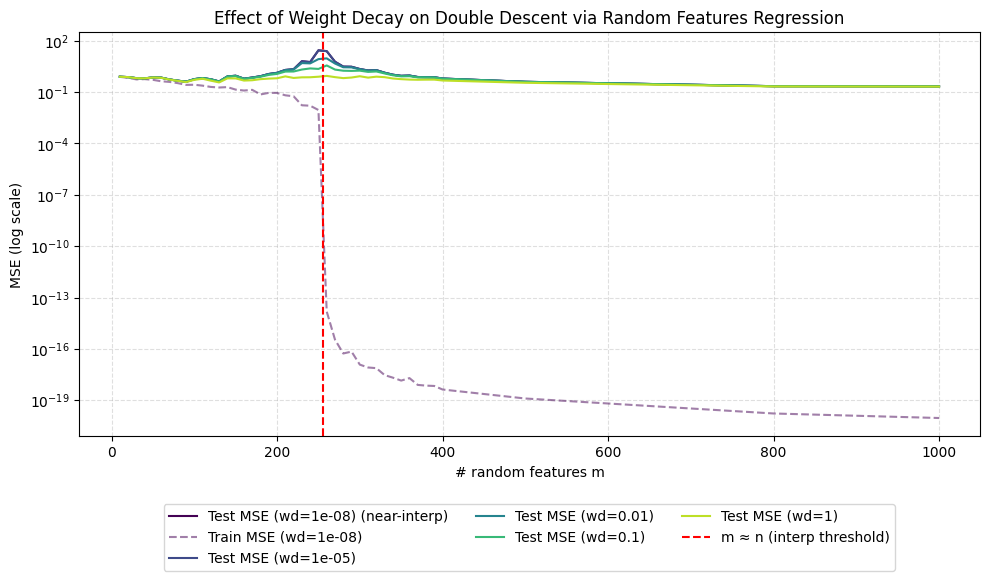

In [40]:
# Attempt 4A: Random Features Regression (clean, paper-style double descent)
# WITH WEIGHT DECAY SWEEP

import numpy as np
import matplotlib.pyplot as plt

# Using a hardcoded seed so the random features and targets are reproducible
SEED = 42 
rng = np.random.default_rng(SEED)

# --- DGP ---
n_train = 256
n_test  = 4096
d_in    = 50
noise_std = 0.5

Xtr = rng.standard_normal((n_train, d_in))
Xte = rng.standard_normal((n_test,  d_in))

# teacher is linear in input space (clean + stable)
w_star = rng.standard_normal(d_in) / np.sqrt(d_in)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + noise_std * rng.standard_normal(n_train)
yte = yte_clean  # evaluate against clean teacher

# normalize targets (optional but makes scales nice)
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

# --- Random feature map: phi(x) = relu(Wx / sqrt(d)) ---
def relu(z): return np.maximum(z, 0.0)

# Sweep #features m (capacity)
ms = list(range(10, 401, 10)) + [500, 800, 1000]

# --- Sweep over Regularization (Weight Decay) ---
ridges = [1e-8, 1e-5, 1e-2, 1e-1,  1.0]

train_mse_all = {r: [] for r in ridges}
test_mse_all  = {r: [] for r in ridges}

for m in ms:
    # Ensure all ridge values share the exact same random features
    W = rng.standard_normal((m, d_in)) / np.sqrt(d_in)  # fixed random first layer

    Phi_tr = relu(Xtr @ W.T)  # (n, m)
    Phi_te = relu(Xte @ W.T)
    
    # Precompute to avoid re-multiplying for every ridge 
    Phi_tr_T_Phi_tr = Phi_tr.T @ Phi_tr
    Phi_tr_T_ytr = Phi_tr.T @ ytr

    for ridge in ridges:
        # Solve ridge regression in feature space:
        # beta = argmin ||Phi beta - y||^2 + ridge ||beta||^2
        # Closed form: beta = (Phi^T Phi + ridge I)^(-1) Phi^T y
        A = Phi_tr_T_Phi_tr + ridge * np.eye(m)
        b = Phi_tr_T_ytr
        
        # solve
        beta = np.linalg.solve(A, b)

        yhat_tr = Phi_tr @ beta
        yhat_te = Phi_te @ beta

        train_mse_all[ridge].append(np.mean((yhat_tr - ytr) ** 2))
        test_mse_all[ridge].append(np.mean((yhat_te - yte) ** 2))


# --- Plot double descent ---
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(ridges)))

for i, ridge in enumerate(ridges):
    label_suffix = " (near-interp)" if ridge == 1e-8 else ""
    plt.plot(ms, test_mse_all[ridge], color=colors[i], label=f"Test MSE (wd={ridge:g}){label_suffix}")
    
    # Only plot train MSE for the smallest ridge to keep the plot clean
    if ridge == 1e-8:
        plt.plot(ms, train_mse_all[ridge], color=colors[i], linestyle="--", alpha=0.5, label=f"Train MSE (wd={ridge:g})")

plt.axvline(n_train, color="red", linestyle="--", linewidth=1.5, label="m ≈ n (interp threshold)")
plt.yscale("log")
plt.xlabel("# random features m")
plt.ylabel("MSE (log scale)")
plt.title("Effect of Weight Decay on Double Descent via Random Features Regression")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
# Move legend outside since it will be tall
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

# Find interpolation idx for smallest ridge
interp_mask = np.array(train_mse_all[1e-8]) < 1e-8
if interp_mask.any():
    print("Interpolation (for wd=1e-8) starts at m =", ms[np.where(interp_mask)[0][0]])

plt.tight_layout()
plt.show()

## Experiment 2: Regularization-wise Double Descent
Fix width at interpolation threshold and sweep weight decay.

"At the most dangerous capacity level, what happens if I dial up the regularization from zero to large values?"

Interpolation (for wd=1e-8) starts at m = 260


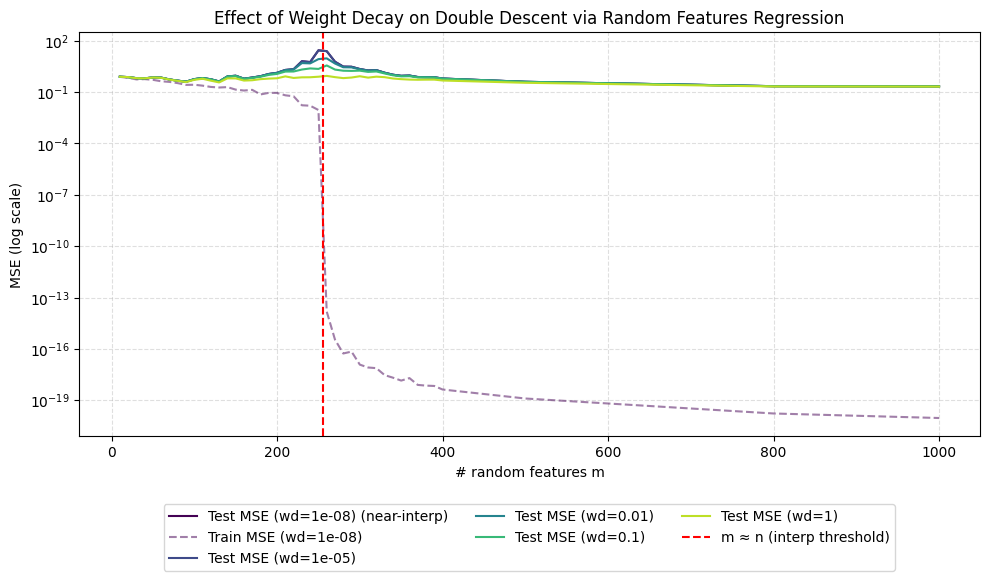

In [41]:
# Attempt 4A: Random Features Regression (clean, paper-style double descent)
# WITH WEIGHT DECAY SWEEP

# Using a hardcoded seed so the random features and targets are reproducible
SEED = 42 
rng = np.random.default_rng(SEED)

# --- DGP ---
n_train = 256
n_test  = 4096
d_in    = 50
noise_std = 0.5

Xtr = rng.standard_normal((n_train, d_in))
Xte = rng.standard_normal((n_test,  d_in))

# teacher is linear in input space (clean + stable)
w_star = rng.standard_normal(d_in) / np.sqrt(d_in)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + noise_std * rng.standard_normal(n_train)
yte = yte_clean  # evaluate against clean teacher

# normalize targets (optional but makes scales nice)
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

# --- Random feature map: phi(x) = relu(Wx / sqrt(d)) ---
def relu(z): return np.maximum(z, 0.0)

# Sweep #features m (capacity)
ms = list(range(10, 401, 10)) + [500, 800, 1000]

# --- Sweep over Regularization (Weight Decay) ---
ridges = [1e-8, 1e-5, 1e-2, 1e-1,  1.0]

train_mse_all = {r: [] for r in ridges}
test_mse_all  = {r: [] for r in ridges}

for m in ms:
    # Ensure all ridge values share the exact same random features
    W = rng.standard_normal((m, d_in)) / np.sqrt(d_in)  # fixed random first layer

    Phi_tr = relu(Xtr @ W.T)  # (n, m)
    Phi_te = relu(Xte @ W.T)
    
    # Precompute to avoid re-multiplying for every ridge 
    Phi_tr_T_Phi_tr = Phi_tr.T @ Phi_tr
    Phi_tr_T_ytr = Phi_tr.T @ ytr

    for ridge in ridges:
        # Solve ridge regression in feature space:
        # beta = argmin ||Phi beta - y||^2 + ridge ||beta||^2
        # Closed form: beta = (Phi^T Phi + ridge I)^(-1) Phi^T y
        A = Phi_tr_T_Phi_tr + ridge * np.eye(m)
        b = Phi_tr_T_ytr
        
        # solve
        beta = np.linalg.solve(A, b)

        yhat_tr = Phi_tr @ beta
        yhat_te = Phi_te @ beta

        train_mse_all[ridge].append(np.mean((yhat_tr - ytr) ** 2))
        test_mse_all[ridge].append(np.mean((yhat_te - yte) ** 2))


# --- Plot double descent ---
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(ridges)))

for i, ridge in enumerate(ridges):
    label_suffix = " (near-interp)" if ridge == 1e-8 else ""
    plt.plot(ms, test_mse_all[ridge], color=colors[i], label=f"Test MSE (wd={ridge:g}){label_suffix}")
    
    # Only plot train MSE for the smallest ridge to keep the plot clean
    if ridge == 1e-8:
        plt.plot(ms, train_mse_all[ridge], color=colors[i], linestyle="--", alpha=0.5, label=f"Train MSE (wd={ridge:g})")

plt.axvline(n_train, color="red", linestyle="--", linewidth=1.5, label="m ≈ n (interp threshold)")
plt.yscale("log")
plt.xlabel("# random features m")
plt.ylabel("MSE (log scale)")
plt.title("Effect of Weight Decay on Double Descent via Random Features Regression")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
# Move legend outside since it will be tall
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

# Find interpolation idx for smallest ridge
interp_mask = np.array(train_mse_all[1e-8]) < 1e-8
if interp_mask.any():
    print("Interpolation (for wd=1e-8) starts at m =", ms[np.where(interp_mask)[0][0]])

plt.tight_layout()
plt.show()

## Experiment 3: Noise vs. Optimal Regularization

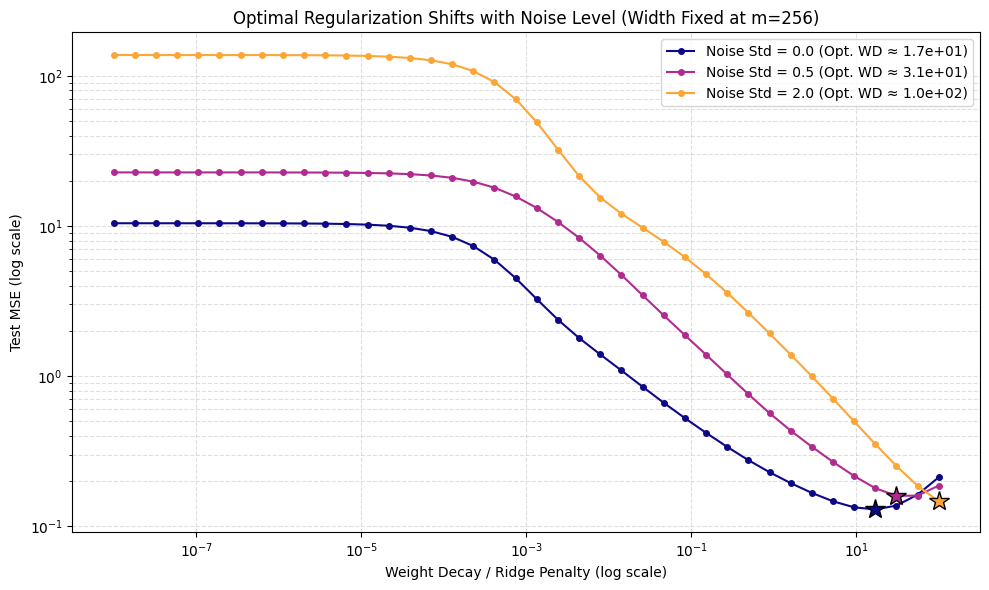

In [42]:
# --- Experiment 3: Noise Level vs. Optimal Regularization ---

import numpy as np
import matplotlib.pyplot as plt

SEED = 42 
rng = np.random.default_rng(SEED)

# --- Base DGP Parameters ---
n_train = 256
n_test  = 4096
d_in    = 50

# Sweep over noise levels
noise_levels = [0.0, 0.5, 2.0]

# Fix capacity at the interpolation threshold (where it matters most)
m_peak = n_train

# Sweep over regularization (Weight Decay/Ridge)
ridges_noise_exp = np.logspace(-8, 2, 40)

# Precalculate random features
Xte = rng.standard_normal((n_test,  d_in))
Xtr = rng.standard_normal((n_train, d_in))

W = rng.standard_normal((m_peak, d_in)) / np.sqrt(d_in)

def relu(z): return np.maximum(z, 0.0)

Phi_tr = relu(Xtr @ W.T)
Phi_te = relu(Xte @ W.T)

Phi_tr_T_Phi_tr = Phi_tr.T @ Phi_tr

# Clean teacher
w_star = rng.standard_normal(d_in) / np.sqrt(d_in)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

plt.figure(figsize=(10, 6))

colors = plt.cm.plasma(np.linspace(0, 0.8, len(noise_levels)))

for i, n_std in enumerate(noise_levels):
    
    # Generate noisy targets for this specific train set
    ytr = ytr_clean + n_std * rng.standard_normal(n_train)
    yte = yte_clean  # Evaluate against clean teacher always
    
    # Normalize targets
    y_mean = ytr.mean()
    y_std  = ytr.std() + 1e-8
    ytr = (ytr - y_mean) / y_std
    yte = (yte - y_mean) / y_std
    
    Phi_tr_T_ytr = Phi_tr.T @ ytr
    
    test_mse_noise = []
    
    for ridge in ridges_noise_exp:
        # Solve ridge regression
        A = Phi_tr_T_Phi_tr + ridge * np.eye(m_peak)
        b = Phi_tr_T_ytr
        
        beta = np.linalg.solve(A, b)

        yhat_te = Phi_te @ beta
        test_mse_noise.append(np.mean((yhat_te - yte) ** 2))
    
    # Optional: Find minimum test MSE to mark it
    min_idx = np.argmin(test_mse_noise)
    opt_ridge = ridges_noise_exp[min_idx]
    
    plt.plot(ridges_noise_exp, test_mse_noise, marker="o", markersize=4, 
             color=colors[i], label=f"Noise Std = {n_std} (Opt. WD ≈ {opt_ridge:.1e})")
    
    # Plot a star at the optimal ridge value
    plt.plot(opt_ridge, test_mse_noise[min_idx], marker="*", markersize=15, 
             color=colors[i], markeredgecolor='black')


plt.xscale('log')
plt.yscale('log')
plt.xlabel('Weight Decay / Ridge Penalty (log scale)')
plt.ylabel('Test MSE (log scale)')
plt.title(f'Optimal Regularization Shifts with Noise Level (Width Fixed at m={m_peak})')
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()



## Experiment 4: Early Stopping (Implicit Regularization)

Running Gradient Descent up to 10000 steps...


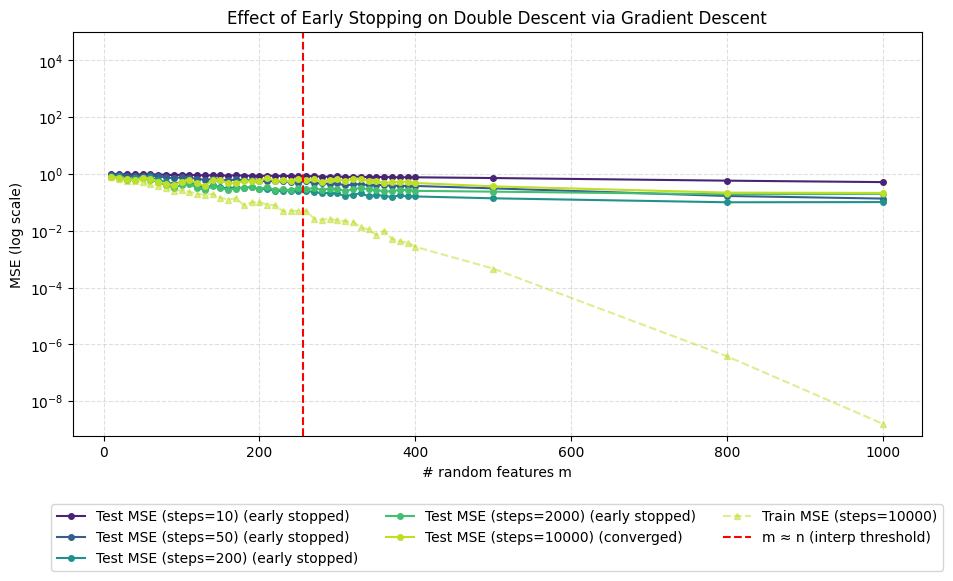

In [43]:
# --- Experiment 4: Early Stopping (Implicit Regularization) ---
# We solve the same Random Features Regression, but instead of the analytical closed form,
# we use Gradient Descent to find the solution iteratively.
# Stopping at different numbers of steps (epochs) acts as implicit regularization.

import numpy as np
import matplotlib.pyplot as plt

SEED = 42 
rng = np.random.default_rng(SEED)

# --- DGP ---
n_train = 256
n_test  = 4096
d_in    = 50
noise_std = 0.5

Xtr = rng.standard_normal((n_train, d_in))
Xte = rng.standard_normal((n_test,  d_in))

w_star = rng.standard_normal(d_in) / np.sqrt(d_in)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + noise_std * rng.standard_normal(n_train)
yte = yte_clean  

y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

def relu(z): return np.maximum(z, 0.0)

# Sweep #features m (capacity)
ms = list(range(10, 401, 10)) + [500, 800, 1000]

# --- Sweep over early stopping epochs (iterations) ---
step_snapshots = [10, 50, 200, 2000, 10000]

# Reduced learning rate to prevent Gradient Descent from exploding to infinity
lr = 0.01

train_mse_all = {s: [] for s in step_snapshots}
test_mse_all  = {s: [] for s in step_snapshots}

max_steps = max(step_snapshots)

print(f"Running Gradient Descent up to {max_steps} steps...")

for m in ms:
    W = rng.standard_normal((m, d_in)) / np.sqrt(d_in)

    Phi_tr = relu(Xtr @ W.T)  
    Phi_te = relu(Xte @ W.T)
    
    beta = np.zeros(m)
    
    Phi_tr_T_Phi_tr = Phi_tr.T @ Phi_tr
    Phi_tr_T_ytr = Phi_tr.T @ ytr

    for step in range(1, max_steps + 1):
        # Gradient Update
        grad = Phi_tr_T_Phi_tr @ beta - Phi_tr_T_ytr
        beta = beta - lr * (grad / n_train)
        
        if step in step_snapshots:
            yhat_tr = Phi_tr @ beta
            yhat_te = Phi_te @ beta
            
            # Calculate MSE and defensively replace NaN/Inf 
            tr_mse = np.nan_to_num(np.mean((yhat_tr - ytr) ** 2), nan=1e10, posinf=1e10)
            te_mse = np.nan_to_num(np.mean((yhat_te - yte) ** 2), nan=1e10, posinf=1e10)

            train_mse_all[step].append(tr_mse)
            test_mse_all[step].append(te_mse)

# --- Plot double descent ---
plt.figure(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(step_snapshots)))

for i, s in enumerate(step_snapshots):
    label_suffix = " (early stopped)" if s < max_steps else " (converged)"
    
    # Clip limits defensively for plotting to strictly prevent OverflowError
    test_plot_y = np.clip(test_mse_all[s], a_min=1e-10, a_max=1e6)
    train_plot_y = np.clip(train_mse_all[s], a_min=1e-10, a_max=1e6)
    
    plt.plot(ms, test_plot_y, color=colors[i], marker="o", markersize=4, label=f"Test MSE (steps={s}){label_suffix}")
    
    if s == max_steps:
        plt.plot(ms, train_plot_y, color=colors[i], marker="^", markersize=4, linestyle="--", alpha=0.5, label=f"Train MSE (steps={s})")

plt.axvline(n_train, color="red", linestyle="--", linewidth=1.5, label="m ≈ n (interp threshold)")
plt.yscale("log")
# Set a safe upper bound on the chart so extreme exploding lines don't break layout
plt.ylim(top=1e5) 

plt.xlabel("# random features m")
plt.ylabel("MSE (log scale)")
plt.title("Effect of Early Stopping on Double Descent via Gradient Descent")
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)
plt.tight_layout()
plt.show()


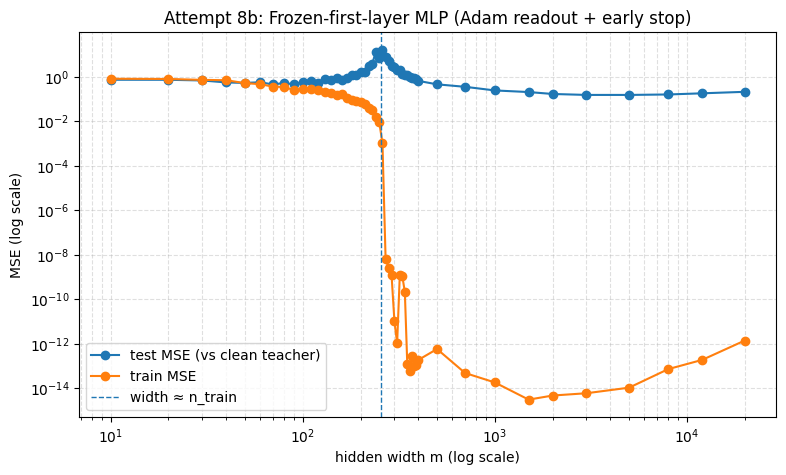

In [53]:
# Attempt 8b: Frozen-first-layer MLP (train readout) — ensure interpolation
import torch.nn as nn
import time

# --- Same data as Attempt 7/8 for comparability ---
N_TRAIN = 256
N_TEST  = 4096
D_IN    = 50
NOISE_STD = 0.5

g = torch.Generator(device="cpu")
g.manual_seed(SEED)

Xtr = torch.randn(N_TRAIN, D_IN, generator=g).to(device)
Xte = torch.randn(N_TEST,  D_IN, generator=g).to(device)

w_star = (torch.randn(D_IN, generator=g) / np.sqrt(D_IN)).to(device)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + NOISE_STD * torch.randn(N_TRAIN, generator=g).to(device)
yte = yte_clean

# normalize
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

class FrozenTwoLayerReLU(nn.Module):
    def __init__(self, d_in: int, width: int):
        super().__init__()
        self.fc1 = nn.Linear(d_in, width, bias=False)
        self.fc2 = nn.Linear(width, 1, bias=False)

        nn.init.normal_(self.fc1.weight, mean=0.0, std=1.0/np.sqrt(d_in))
        for p in self.fc1.parameters():
            p.requires_grad = False

        nn.init.zeros_(self.fc2.weight)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x))).squeeze(-1)

def count_params_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def mse(model, x, y, batch_size=2048):
    model.eval()
    n = x.shape[0]
    total = 0.0
    for i in range(0, n, batch_size):
        xb = x[i:i+batch_size]
        yb = y[i:i+batch_size]
        pred = model(xb)
        total += torch.mean((pred - yb) ** 2).item() * xb.shape[0]
    return total / n

# --- Wider sweep REALLY into m >> n ---
widths = list(range(10, 401, 10)) + [500, 700, 1000, 1500, 2000, 3000, 5000, 8000, 12000, 20000]

# Optimizer settings for readout
LR = 1e-2
MAX_STEPS = 200000
LOG_EVERY = 5000
TARGET_TRAIN_MSE = 1e-8  # interpolation criterion

rows_8b = []
t0_all = time.time()

for w in widths:
    seed_all(SEED)
    model = FrozenTwoLayerReLU(D_IN, w).to(device)

    # Adam converges more reliably for large widths
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    t0 = time.time()
    steps_done = 0

    for step in range(1, MAX_STEPS + 1):
        model.train()
        pred = model(Xtr)
        loss = loss_fn(pred, ytr)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if step % LOG_EVERY == 0 or step == 1:
            tr_now = mse(model, Xtr, ytr)
            if tr_now < TARGET_TRAIN_MSE:
                steps_done = step
                break

    if steps_done == 0:
        steps_done = MAX_STEPS

    wall = time.time() - t0

    tr = mse(model, Xtr, ytr)
    te = mse(model, Xte, yte)

    row = {
        "experiment": "01_attempt8b_frozen_mlp_readout_adam_earlystop",
        "seed": SEED,
        "n_train": N_TRAIN,
        "n_test": N_TEST,
        "d_in": D_IN,
        "noise_std": NOISE_STD,
        "mlp_type": "2layer_relu_frozen_first",
        "width": w,
        "optimizer": "adam",
        "lr": LR,
        "steps": steps_done,
        "params_trainable": count_params_trainable(model),
        "train_mse": tr,
        "test_mse_clean": te,
        "wall_sec": wall,
    }
    rows_8b.append(row)
    # append_row_csv(CSV_PATH, row)

# print("Logged to:", CSV_PATH, "| total wall:", round(time.time() - t0_all, 1), "sec")

# --- Plot ---
m_cap = np.array([r["width"] for r in rows_8b])
train_mse_arr = np.array([r["train_mse"] for r in rows_8b])
test_mse_arr  = np.array([r["test_mse_clean"] for r in rows_8b])
order = np.argsort(m_cap)
m_cap, train_mse_arr, test_mse_arr = m_cap[order], train_mse_arr[order], test_mse_arr[order]
# Clip to a small positive floor so log scale doesn't break
train_mse_arr = np.clip(train_mse_arr, 1e-15, None)
test_mse_arr  = np.clip(test_mse_arr,  1e-15, None)
fig = plt.figure(figsize=(9,5))
plt.plot(m_cap, test_mse_arr, marker="o", label="test MSE (vs clean teacher)")
plt.plot(m_cap, train_mse_arr, marker="o", label="train MSE")
plt.axvline(N_TRAIN, linestyle="--", linewidth=1, label="width ≈ n_train")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("hidden width m (log scale)")
plt.ylabel("MSE (log scale)")
plt.title("Attempt 8b: Frozen-first-layer MLP (Adam readout + early stop)")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.show()

# out_path = FIG_DIR / "01_attempt8b_frozen_mlp_adam_earlystop.png"
# fig.savefig(out_path, dpi=300, bbox_inches="tight")
# print("Figure saved to:", out_path)
plt.show()

--- Sweeping with Weight Decay: 0.0 ---
--- Sweeping with Weight Decay: 0.001 ---
--- Sweeping with Weight Decay: 0.1 ---
Done! Total wall time: 490.9 sec


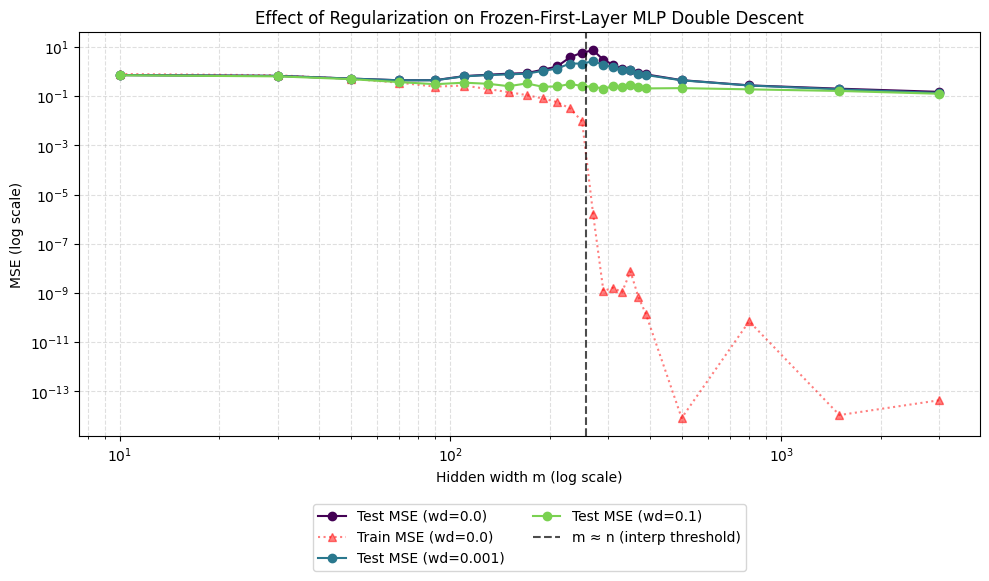

In [54]:
# Attempt 8b: Frozen-first-layer MLP (train readout) — ensure interpolation WITH REGULARIZATION

# --- Same data as Attempt 7/8 for comparability ---
N_TRAIN = 256
N_TEST  = 4096
D_IN    = 50
NOISE_STD = 0.5
SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
g = torch.Generator(device="cpu")
g.manual_seed(SEED)

Xtr = torch.randn(N_TRAIN, D_IN, generator=g).to(device)
Xte = torch.randn(N_TEST,  D_IN, generator=g).to(device)

w_star = (torch.randn(D_IN, generator=g) / np.sqrt(D_IN)).to(device)
ytr_clean = Xtr @ w_star
yte_clean = Xte @ w_star

ytr = ytr_clean + NOISE_STD * torch.randn(N_TRAIN, generator=g).to(device)
yte = yte_clean

# normalize
y_mean = ytr.mean()
y_std  = ytr.std() + 1e-8
ytr = (ytr - y_mean) / y_std
yte = (yte - y_mean) / y_std

class FrozenTwoLayerReLU(nn.Module):
    def __init__(self, d_in: int, width: int):
        super().__init__()
        self.fc1 = nn.Linear(d_in, width, bias=False)
        self.fc2 = nn.Linear(width, 1, bias=False)

        nn.init.normal_(self.fc1.weight, mean=0.0, std=1.0/np.sqrt(d_in))
        for p in self.fc1.parameters():
            p.requires_grad = False

        nn.init.zeros_(self.fc2.weight)

    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x))).squeeze(-1)

def count_params_trainable(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

@torch.no_grad()
def mse(model, x, y, batch_size=2048):
    model.eval()
    n = x.shape[0]
    total = 0.0
    for i in range(0, n, batch_size):
        xb = x[i:i+batch_size]
        yb = y[i:i+batch_size]
        pred = model(xb)
        total += torch.mean((pred - yb) ** 2).item() * xb.shape[0]
    return total / n

# --- Settings ---
# Fewer granular points plotted to speed up execution slightly
widths = list(range(10, 401, 20)) + [500, 800, 1500, 3000]

LR = 1e-2
# Dropped max steps slightly for interactive speed
MAX_STEPS = 50000 
TARGET_TRAIN_MSE = 1e-8  # interpolation criterion

# We will sweep across 3 regularization strengths
weight_decays = [0.0, 1e-3, 1e-1]

# Store results
results = {wd: {"train": [], "test": []} for wd in weight_decays}

t0_all = time.time()

for wd in weight_decays:
    print(f"--- Sweeping with Weight Decay: {wd} ---")
    for w in widths:
        # Reset seeds for comparability across widths
        g.manual_seed(SEED)
        torch.manual_seed(SEED)
        np.random.seed(SEED)
        
        model = FrozenTwoLayerReLU(D_IN, w).to(device)

        # Adam converges more reliably for large widths. Add L2 penalty via weight_decay arg.
        opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=wd)
        loss_fn = nn.MSELoss()

        for step in range(1, MAX_STEPS + 1):
            model.train()
            pred = model(Xtr)
            loss = loss_fn(pred, ytr)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            # Early checking stopping more frequently (every 1000 steps instead of 5000)
            if step % 1000 == 0 or step == 1:
                tr_now = mse(model, Xtr, ytr)
                if tr_now < TARGET_TRAIN_MSE:
                    break

        tr = mse(model, Xtr, ytr)
        te = mse(model, Xte, yte)

        results[wd]["train"].append(tr)
        results[wd]["test"].append(te)


print("Done! Total wall time:", round(time.time() - t0_all, 1), "sec")

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Define colors for overlaid sweeps
colors = plt.cm.viridis(np.linspace(0, 0.8, len(weight_decays)))

for i, wd in enumerate(weight_decays):
    # Floor to prevent matplotlib log scaling from throwing ValueError for 0s
    test_err = np.clip(results[wd]["test"], 1e-15, None)
    train_err = np.clip(results[wd]["train"], 1e-15, None)
    
    plt.plot(widths, test_err, color=colors[i], marker="o", label=f"Test MSE (wd={wd})")
    
    # We generally only care about graphing Training MSE on the absolute baseline
    if wd == 0.0:
        plt.plot(widths, train_err, color="red", marker="^", linestyle=":", alpha=0.5, label="Train MSE (wd=0.0)")

plt.axvline(N_TRAIN, linestyle="--", color="black", linewidth=1.5, alpha=0.7, label="m ≈ n (interp threshold)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Hidden width m (log scale)")
plt.ylabel("MSE (log scale)")
plt.title("Effect of Regularization on Frozen-First-Layer MLP Double Descent")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()


ValueError: min() iterable argument is empty

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 900x500 with 1 Axes>